# Q-Learning

In [1]:
import numpy as np
import random

In [2]:
grid = [['S', 'X', ' ', ' ', ' '],
        [' ', ' ', ' ', 'X', ' '],
        [' ', 'X', ' ', 'Z', ' ']]

rows, cols = np.array(grid).shape
actions = ['Hoch', 'Runter', 'Links', 'Rechts']

alpha = 0.1
gamma = 0.2
epsilon = 0.1

## Übung

In [3]:
def decide_epsilon_greedy(row, col):
    # Triff eine Wahl in welche Richtung der Agent gehen soll (Epsilon-Greedy Strategie)
    return # Richtung

def step(row, col, action):
    # Basierend auf Position und Richtung, aktualisiere die Position
    new_row, new_col = row, col
    if action == "Hoch" and row > 0:
        new_row -= 1
    elif action == "Runter" and row < (rows - 1):
        new_row += 1
    elif action == "Links" and col > 0:
        new_col -= 1
    elif action == "Rechts" and col < (cols - 1):
        new_col += 1
    return new_row, new_col

def get_reward(row, col):
    # Basierend auf der aktuellen Position, entscheide die Belohnung die der Agent erhält
    return # float

In [6]:
# Initialisieren der Q-Werte Matrix
q_values = np.zeros((rows, cols, len(actions)))

# Lern-Episonen
for i in range(1000):
    
    # Beginn oben links
    row, col = (0, 0)

    # Solange das Ziel noch nicht erreicht ist...
    while grid[row][col] != "Z":
        #epsilon greedy
        #get_reward()
        #step()
        #q_values[::] = ??
        # Implementierung hier
        break  # Platzhalter um Endlosschleife zu vermeiden

q_values

array([[[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]])

## Lösung / Implementierung

In [7]:
def decide_epsilon_greedy(row, col):
    if random.uniform(0, 1) <= epsilon:
        return random.choice(actions)
    else:
        return actions[np.argmax(q_values[row, col, :])]

def step(row, col, action):
    new_row, new_col = row, col
    if action == "Hoch" and row > 0:
        new_row -= 1
    elif action == "Runter" and row < rows - 1:
        new_row += 1
    elif action == "Links" and col > 0:
        new_col -= 1
    elif action == "Rechts" and col < cols - 1:
        new_col += 1
    return new_row, new_col

def get_reward(row, col):
    match grid[row][col]:
        case "Z": return 10
        case "X": return -10
        case _: return -0.5

In [8]:
q_values = np.zeros((rows, cols, len(actions)))
for i in range(1000):
    row, col = (0, 0)
    while grid[row][col] != "Z":
        action = decide_epsilon_greedy(row, col)
        next_row, next_col = step(row, col, action)
        reward = get_reward(next_row, next_col)

        
        q_values[row, col, actions.index(action)] = q_values[row, col, actions.index(action)] + alpha * (reward + gamma * np.max(q_values[next_row, next_col, :]) - q_values[row, col, actions.index(action)])
        
        # Alternative Form derselben Gleichung die zu den gleichen Ergebnisse führt (einfach nur ausmulitpliziert und vereinfacht)
        # q_values[row, col, actions.index(action)] = (1 - alpha) * q_values[row, col, actions.index(action)] + alpha * (reward + gamma * np.max(q_values[next_row, next_col, :]))

        row, col = next_row, next_col

q_values
actions = ['Hoch', 'Runter', 'Links', 'Rechts']


In [9]:
np.vectorize(lambda x: actions[x])(q_values.argmax(axis=2))

array([['Runter', 'Rechts', 'Runter', 'Rechts', 'Links'],
       ['Rechts', 'Rechts', 'Runter', 'Runter', 'Rechts'],
       ['Runter', 'Rechts', 'Rechts', 'Hoch', 'Links']], dtype='<U6')

|   |   |   |   |   |
|---|---|---|---|---|
| . | X |   |   |   |
| . | . | . | X |   |
|   | X | . | Z |   |

In [10]:
row, col = 0, 0
steps = 0
while grid[row][col] != "Z":
    action = actions[np.argmax(q_values[row, col, :])]
    print(action)
    next_row, next_col = step(row, col, action)
    row, col = next_row, next_col
    steps += 1

print("\nAnzahl der Schritte:", steps)

Runter
Rechts
Rechts
Runter
Rechts

Anzahl der Schritte: 5


In [11]:
q_values = np.zeros((rows, cols, len(actions)))

for i in range(2000):
    row, col = (0, 0)
    while grid[row][col] != "Z":
        action = decide_epsilon_greedy(row, col)
        next_row, next_col = step(row, col, action)
        reward = get_reward(next_row, next_col)

        q_values[row, col, actions.index(action)] = (1 - alpha) * q_values[row, col, actions.index(action)] + alpha * (reward + gamma * np.max(q_values[next_row, next_col, :]))
        row, col = next_row, next_col

row, col = (0, 0)
while grid[row][col] != "Z":
    action = decide_epsilon_greedy(row, col)
    next_row, next_col = step(row, col, action)
    reward = get_reward(next_row, next_col)

    q_old = q_values[row, col, actions.index(action)]
    epsilon_greedy = "Dies war eine zufällige Entscheidung" if (action != actions[np.argmax(q_values[row, col, :])]) else "Dies war die beste Entscheidung"
    q_values[row, col, actions.index(action)] = (1 - alpha) * q_values[row, col, actions.index(action)] + alpha * (reward + gamma * np.max(q_values[next_row, next_col, :]))

    print(f"Ich stehe auf Feld {row, col} und gehe {action}, diese Kombination hat einen Q-Wert von {np.round(q_old,2)}.\
            \n{epsilon_greedy} gemäß dem Epsilon-Greedy Prinzip. \
            \nMeine Belohnung dafür ist {reward} und der maximale Q-Wert des neuen Feldes ist {np.round(np.max(q_values[next_row, next_col, :]))}\
            \nIch update entsprechend meinen Q-Wert von {np.round(q_old,2)} auf {np.round(q_values[row, col, actions.index(action)],2)}\n")
    
    row, col = next_row, next_col

print("Ich bin im Ziel angelangt.")

Ich stehe auf Feld (0, 0) und gehe Runter, diese Kombination hat einen Q-Wert von -0.61.            
Dies war die beste Entscheidung gemäß dem Epsilon-Greedy Prinzip.             
Meine Belohnung dafür ist -0.5 und der maximale Q-Wert des neuen Feldes ist -1.0            
Ich update entsprechend meinen Q-Wert von -0.61 auf -0.61

Ich stehe auf Feld (1, 0) und gehe Rechts, diese Kombination hat einen Q-Wert von -0.54.            
Dies war die beste Entscheidung gemäß dem Epsilon-Greedy Prinzip.             
Meine Belohnung dafür ist -0.5 und der maximale Q-Wert des neuen Feldes ist -0.0            
Ich update entsprechend meinen Q-Wert von -0.54 auf -0.54

Ich stehe auf Feld (1, 1) und gehe Rechts, diese Kombination hat einen Q-Wert von -0.2.            
Dies war die beste Entscheidung gemäß dem Epsilon-Greedy Prinzip.             
Meine Belohnung dafür ist -0.5 und der maximale Q-Wert des neuen Feldes ist 1.0            
Ich update entsprechend meinen Q-Wert von -0.2 auf -0.2

Ich steh

## UCB Simulation

ValueError: x and y must have same first dimension, but have shapes (98,) and (0,)

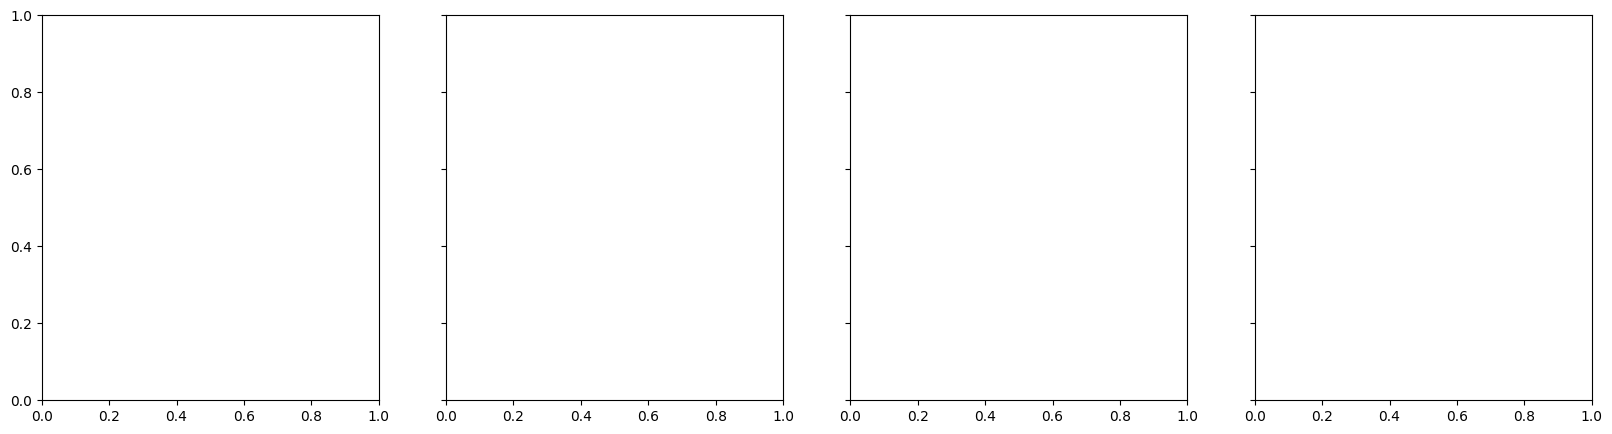

In [ ]:
import matplotlib.pyplot as plt
import math
import random
fig, axs = plt.subplots(1,4, figsize=(20,5), sharey=True)
for j in range(4):
    ucb = []
    play_count = 1
    for i in range(1, 100):
        play_count += 1 if random.uniform(0, 1) > 0.9 else 0
        ucb.append(math.sqrt((2*math.log(i)) / play_count))
        
        axs[j].plot(range(2,100), ucb[1:])
        axs[j].set_title("UCB im Spiel " + str(j+1))
        axs[j].set_xlabel("Runde")
    axs[0].set_ylabel("UCB Wert")
plt.show()

ValueError: x and y must have same first dimension, but have shapes (99,) and (1,)

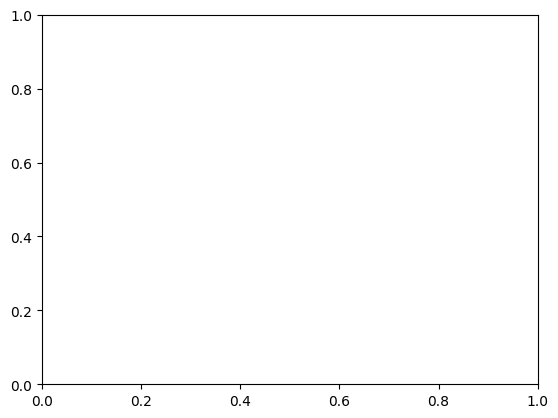

In [15]:
plt.plot(range(1,100), ucb)
plt.title("UCB im Spiel")
plt.xlabel("Runde")
plt.ylabel("UCB Wert")
plt.show()